# Unit 12. Ensembles

精算統計模型 (SOA Exam SRM/PA). The text of [unit12.pdf](https://github.com/chang-ye-tu/asm/blob/master/note/unit12.pdf) with every R chunk as a code cell.

<a href="https://colab.research.google.com/github/chang-ye-tu/asm/blob/master/colab/unit12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The notebook runs on the R runtime (on Colab: Runtime › Change runtime type › R). Run the setup cell first: it installs the packages and downloads the data this unit uses.

In [ ]:
# Setup: run this cell first. It installs the packages this unit uses and downloads
# its data files into data/, the paths the code below reads.
local({
  if (is.null(getOption("repos")) || identical(unname(getOption("repos")["CRAN"]), "@CRAN@"))
    options(repos = c(CRAN = "https://cloud.r-project.org"))
  os <- tryCatch(readLines("/etc/os-release"), error = function(e) character())
  code <- sub("^VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", os, value = TRUE))
  if (length(code) == 1 && nzchar(code))  # Linux, e.g. Colab: prebuilt binary packages
    options(repos = c(CRAN = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", code)),
            HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(), paste(getRversion(),
              R.version$platform, R.version$arch, R.version$os)))
})
pkgs <- c("gbm", "glmnet", "ISLR2", "randomForest", "tree")
new <- setdiff(pkgs, rownames(installed.packages()))
if (length(new)) install.packages(new)
data_files <- c("data/islr/Heart.csv")
for (f in data_files) if (!file.exists(f)) {
  dir.create(dirname(f), recursive = TRUE, showWarnings = FALSE)
  url <- if (startsWith(f, "data/islr/"))
    paste0("https://www.statlearning.com/s/", basename(f)) else
    paste0("https://raw.githubusercontent.com/chang-ye-tu/asm/master/note/", f)
  download.file(url, f, quiet = TRUE, mode = "wb")
}
options(width = 62, digits = 4, scipen = 4, repr.plot.width = 6.4, repr.plot.height = 3.0)

## 1 Bagging

> **Reading.** ISLR §8.2.1 (both reading lists). SRM learning outcome 4(c).

**Remark** (ISLR §8.2.1). A tree has high variance: two halves of one data set can give very different trees. Averaging $B$ independent observations of variance $\sigma^2$ gives variance $\sigma^2/B$, and bootstrap aggregation, or **bagging**, imitates that by averaging trees fitted to bootstrap samples of the one training set. The members are not independent, and the next theorem measures what their correlation costs. Bagging, random forests and boosting are **ensemble** methods: each combines many building-block models, which ISLR calls **weak learners** because each alone may predict only moderately well, into one predictor. For bagging and forests the members are large, low-bias trees whose weakness is their variance; for boosting they are small trees whose weakness is their bias.

### 1.1 Averaging

**Theorem 12.1** (Variance of an average of equicorrelated predictors). Let $Z_1,\ldots,Z_B$ have common variance $\sigma^2>0$ and common pairwise correlation $\rho$. Then

$$
\operatorname{var}\Bigl(\frac1B\sum_{b=1}^{B}Z_b\Bigr)
\;=\;\rho\,\sigma^2\;+\;\frac{1-\rho}{B}\,\sigma^2 , \tag{1}
$$

and, if $B\geqslant2$, necessarily $\rho\geqslant-1/(B-1)$. For $\rho\geqslant0$ the right side decreases in $B$ to the limit $\rho\sigma^2$.

**Proof.** $\operatorname{var}(\sum_bZ_b)=\sum_b\operatorname{var}(Z_b)+\sum_{a\neq b}\operatorname{cov}(Z_a,Z_b) =B\sigma^2+B(B-1)\rho\sigma^2$, since each of the $B(B-1)$ ordered pairs has covariance $\rho\sigma^2$. Dividing by $B^2$,

$$
\operatorname{var}(\bar Z)=\frac{\sigma^2}{B}+\frac{B-1}{B}\rho\sigma^2
=\rho\sigma^2+\frac{\sigma^2(1-\rho)}{B} ,
$$

which is (1). A variance is non-negative, so $B\sigma^2+B(B-1)\rho\sigma^2\geqslant0$ forces $\rho\geqslant-1/(B-1)$. For $\rho\geqslant0$ only the second term of (1) depends on $B$ and it decreases. ∎

**Remark**. The second term of (1) is what averaging removes and it vanishes at rate $1/B$, so, for an average of numbers (a regression, or averaged class probabilities), the number of members is not a tuning parameter: more is never worse. The first term is what averaging cannot touch.

**Corollary 12.2** (The same identity for sample moments). Let $\mathbf{Q}$ be an $M\times B$ matrix with $M,B\geqslant2$, $\hat s_b^2$ the sample variance of its $b$th column and $\hat c$ the average of the $B(B-1)/2$ distinct sample covariances between columns. Then the sample variance of the row means is exactly

$$
\frac{1}{B}\,\overline{\hat s^2}\;+\;\frac{B-1}{B}\,\hat c ,
\qquad \overline{\hat s^2}=\frac1B\sum_b\hat s_b^2 . \tag{2}
$$

**Proof.** The row means are $\mathbf{Q}\mathbf{1}/B$, whose sample variance is $B^{-2}\mathbf{1}'\widehat{\boldsymbol{\Sigma}}\mathbf{1}$ with $\widehat{\boldsymbol{\Sigma}}$ the sample covariance matrix of the columns. Expanding, $\mathbf{1}'\widehat{\boldsymbol{\Sigma}}\mathbf{1}=\sum_b\hat s_b^2+2\sum_{a<b}\hat c_{ab}=B\overline{\hat s^2}+B(B-1)\hat c$. ∎

**Remark**. Corollary 12.2 is an algebraic identity, not an approximation. Theorem 12.1 is the same statement about population moments and needs the equicorrelation hypothesis; for an ensemble that hypothesis holds by symmetry, the members being built by identical independent randomisations of one procedure.

### 1.2 The bootstrap ensemble

**Definition 12.3** (Bagging). Let $\mathcal{D}^{\ast1},\ldots,\mathcal{D}^{\ast B}$ be independent bootstrap samples of the training data (Unit 1's definition of the bootstrap) and let $\hat f^{\ast b}$ be the predictor fitted to $\mathcal{D}^{\ast b}$. The **bagged** predictor is

$$
\hat f_{\mathrm{bag}}(\mathbf{x})=\frac1B\sum_{b=1}^{B}\hat f^{\ast b}(\mathbf{x}) \tag{3}
$$

for regression, and for classification the class receiving the most votes among $\hat f^{\ast1}(\mathbf{x}),\ldots,\hat f^{\ast B}(\mathbf{x})$. The trees are grown large and not pruned.

**Proposition 12.4** (Bagging moves variance, not bias). For regression (or averaged class probabilities), the $\hat f^{\ast b}(\mathbf{x})$ are identically distributed, so $\operatorname{\mathsf{E}}[\hat f_{\mathrm{bag}}(\mathbf{x})]=\operatorname{\mathsf{E}}[\hat f^{\ast1}(\mathbf{x})]$: the ensemble has exactly the bias of one of its members. Its variance is (1) and, for $\sigma^2>0$, is strictly smaller than a member's whenever $\rho<1$ and $B\geqslant2$.

**Proof.** Expectation is linear and the terms are identically distributed. For the variance, the difference between $\sigma^2$ and (1) is $(1-\rho)\sigma^2(1-1/B)$, positive when $\rho<1$ and $B>1$. ∎

**Remark**. The trees are left unpruned. Pruning trades variance for bias (Unit 11), and the averaging in (3) already removes variance at no cost in bias, so the member to feed it is the one with the least bias available. The two devices would otherwise be paying twice for the same thing.

**Remark**. The bias is that of a tree fitted to a **bootstrap** sample, not to the original data. Proposition 12.4 says the averaging introduces no bias; it does not say the bagged predictor has the bias of a tree fitted to $\mathcal{D}$. Resampling makes the members differ, and paying a little bias for that is the trade bagging makes.

**Remark** (ISLR §8.2.1). ISLR grows the $B$ trees deep and unpruned, so each has high variance and low bias, and notes that $B$ is not a critical parameter: a very large $B$ does not overfit, and $B=100$ already suffices in its example. For regression, or for averaged class probabilities, that is Theorem 12.1: the variance decreases in $B$ and the bias, by Proposition 12.4, does not depend on it. For a qualitative response the bagged prediction is the majority vote, which the next proposition examines.

**Proposition 12.5** (Majority vote under independence). Fix $\mathbf{x}$ and suppose the $B$ classifiers are independent and each correct with probability $\pi>\tfrac12$. Then the majority vote is correct with probability at least

$$
1-\frac{\pi(1-\pi)}{B\,(\pi-\tfrac12)^2}\ \longrightarrow\ 1 . \tag{4}
$$

**Proof.** The number $N$ of correct classifiers is binomial with mean $B\pi$ and variance $B\pi(1-\pi)$. The vote is wrong only if $N\leqslant B/2$, that is $N-B\pi\leqslant-B(\pi-\tfrac12)$, and the prerequisites' theorem **Markov, Chebyshev** bounds that probability by $B\pi(1-\pi)/\{B(\pi-\tfrac12)\}^2$. ∎

**Remark**. The hypothesis is independence, and ensemble members built from one data set are not independent: that is what $\rho>0$ means. Proposition 12.5 is therefore an account of why voting could help, not a guarantee that it does, and the size of $\rho$ decides how much of the promised gain survives. The same caution applies to (1), where $\rho\sigma^2$ is the part that no amount of averaging removes.

### 1.3 Out-of-bag estimation

**Definition 12.6** (Out-of-bag prediction). Let $\mathcal{O}_i=\{b:\text{index } i \text{ is not drawn into }\mathcal{D}^{\ast b}\}$ and $B_i=|\mathcal{O}_i|$. For the $i$ with $B_i\geqslant1$, the **out-of-bag** prediction for observation $i$ is $\hat f_{\mathrm{oob}}(\mathbf{x}_i)=B_i^{-1}\sum_{b\in\mathcal{O}_i}\hat f^{\ast b}(\mathbf{x}_i)$, and the out-of-bag error is the average of $\{y_i-\hat f_{\mathrm{oob}}(\mathbf{x}_i)\}^2$ over those $i$. For classification, $\hat f_{\mathrm{oob}}(\mathbf{x}_i)$ is the majority vote over $\mathcal{O}_i$ and the out-of-bag error is the misclassification rate.

**Theorem 12.7** (What out-of-bag estimates). (i) $\operatorname{\mathsf{E}}[B_i]=B(1-1/n)^n$, which increases to $B/e\approx0.368B$.

(ii) Every tree averaged in $\hat f_{\mathrm{oob}}(\mathbf{x}_i)$ was fitted without $(\mathbf{x}_i,y_i)$, so the prediction is out of sample.

(iii) Conditionally on $B_i=B'$, idealise the $B'$ out-of-bag members as $B'$ members distributed like all the others (ignoring that a bootstrap sample drawn from the $n-1$ observations other than $i$ differs from one drawn from all $n$), and evaluate at a new point $\mathbf{x}_0$ independent of the data. Then their average has the same mean as the full ensemble and, under the hypotheses of Theorem 12.1, variance larger by

$$
(1-\rho)\sigma^2\Bigl(\frac1{B'}-\frac1B\Bigr) , \tag{5}
$$

so its mean squared error at $\mathbf{x}_0$ exceeds the full ensemble's by that amount, of order $(e-1)(1-\rho)\sigma^2/B$. No comparison holds between $\hat f_{\mathrm{oob}}(\mathbf{x}_i)$ and $\hat f_{\mathrm{bag}}(\mathbf{x}_i)$, whose members include trees that have seen $(\mathbf{x}_i,y_i)$. If the observations are iid, then, since $(\mathbf{x}_i,y_i)$ is independent of the other $n-1$ observations and unseen by the out-of-bag members (part (ii)), the $i$th term of the out-of-bag error is distributed as the squared error at a new point of an average of $B_i$ members each fitted to $n$ draws with replacement from those $n-1$ observations; the idealisation identifies this with the situation at $\mathbf{x}_0$.

**Proof.** (i) By Unit 1's proposition **out-of-bag fraction** each bootstrap sample misses $(\mathbf{x}_i,y_i)$ with probability $(1-1/n)^n$, and $B_i$ counts $B$ independent such events.

(ii) is Definition 12.6.

(iii) Under the idealisation of the statement the $B'$ out-of-bag members are identically distributed with the others, so at $\mathbf{x}_0$ their average has the common mean and, by Theorem 12.1 with $B'$ in place of $B$, variance $\rho\sigma^2+(1-\rho)\sigma^2/B'$. Subtracting the same expression with $B$ gives (5). Two predictors with the same expectation differ in mean squared error by exactly their difference in variance. Substituting $B'=B/e$ gives $(1-\rho)\sigma^2(e-1)/B$. ∎

**Remark** (ISLR §8.2.1). ISLR's account: each bagged tree uses about two thirds of the observations, the remaining third are its out-of-bag observations, and averaging the roughly $B/3$ out-of-bag predictions of observation $i$ gives a valid test prediction for it. Part (i) is the precise fraction, $(1-1/n)^n\to e^{-1}=0.368$. ISLR adds that for large $B$ the out-of-bag error is virtually the leave-one-out cross-validation error of the bagged model, which part (ii) makes plausible but does not prove: no tree in the average has seen observation $i$. It costs no refitting, which is why it is the error estimate used for bagged models on large data sets.

**Remark**. So the out-of-bag error is honest about being out of sample and, under the idealisation of part (iii), is biased **upward** as an estimate of the full ensemble's error at a new point, by an amount that vanishes like $1/B$. At $B=500$ that correction is negligible beside the variability of the estimate itself: on one split of `Boston` the out-of-bag and test errors differ by a factor of $1.8$, and averaged over twenty-five splits by $12\%$.

### 1.4 Variable importance

**Definition 12.8** (Mean decrease in impurity). For a tree $T$ let $\Delta(t)=R(t)-R(t_L)-R(t_R)$ be the cost reduction at internal node $t$, non-negative because the costs of Unit 11 refine (Unit 11's proposition **the three costs of this unit refine**). The **impurity importance** of predictor $j$ in $T$ is $\sum\{\Delta(t):t\text{ splits on }j\}$, and in an ensemble it is the average of that over the members.

**Proposition 12.9** (The importances of a tree add up to what it explains).

$$
\sum_{t\ \mathrm{internal}}\Delta(t)\;=\;R(r)-R(T) , \tag{6}
$$

$r$ being the root. So the impurity importances of all predictors sum to the total cost the tree removes, and, when $R(r)>R(T)$, dividing by $R(r)-R(T)$ turns them into shares.

**Proof.** Write $I$ for the internal nodes and $\mathcal{L}$ for the leaves. Every node except the root is a child of exactly one internal node, so $\sum_{t\in I}\{R(t_L)+R(t_R)\}=\sum_{t\neq r}R(t)=\sum_{t\in I}R(t)-R(r)+\sum_{t\in \mathcal{L}}R(t)$. Subtracting this from $\sum_{t\in I}R(t)$ leaves $R(r)-\sum_{t\in \mathcal{L}}R(t)=R(r)-R(T)$. ∎

**Remark** (ISLR §8.2.1). Bagging improves accuracy at the expense of interpretability: the result is no longer one tree. ISLR's summary is a **variable importance** measure: for a regression tree, the total decrease in the residual sum of squares due to splits on a predictor, averaged over the $B$ trees; for a classification tree, the same with the Gini index. That is Definition 12.8 with the node cost of Unit 11, and Proposition 12.9 turns it into shares.

**Definition 12.10** (Permutation importance). Let $\mathcal{E}$ be a set of observations not used in fitting and $L$ the loss. The **permutation importance** of predictor $j$ is

$$
\frac1{|\mathcal{E}|}\sum_{i\in\mathcal{E}}L\bigl(y_i,\hat f(\mathbf{x}_i^{(j)})\bigr)
-\frac1{|\mathcal{E}|}\sum_{i\in\mathcal{E}}L\bigl(y_i,\hat f(\mathbf{x}_i)\bigr) , \tag{7}
$$

where $\mathbf{x}^{(j)}$ is $\mathbf{x}$ with the $j$th coordinate replaced by its entry in a uniformly random permutation of the $j$th column of $\mathcal{E}$. In a bagged ensemble $\mathcal{E}$ is taken to be the out-of-bag set of each tree.

**Proposition 12.11** (A useless predictor has zero permutation importance). If $X_j$ is independent of $(Y,X_{-j})$ and the observations are independent and identically distributed, then permuting the $j$th column leaves the joint law of $\mathcal{E}$ unchanged, so the expectation of (7), over $\mathcal{E}$ and the permutation, is $0$.

**Proof.** Under independence the joint law of $\mathcal{E}$ is the product of the law of $(Y,X_{-j})$ and the law of $X_j$, which is exchangeable in the $X_j$ coordinate across observations. Permuting that coordinate therefore leaves the joint law unchanged, and the two averages in (7) have the same expectation. ∎

**Remark**. No such statement holds for Definition 12.8. A predictor independent of the response still offers cutpoints, and the best of many cutpoints reduces the training cost by a positive amount; a predictor offering more distinct cutpoints tends to reduce it by more. So impurity importance is positive for pure noise and tends to increase with the number of candidate splits the predictor offers ($n-1$ for a continuous predictor, $2^{k-1}-1$ for a $k$-level factor); on four noise variables the impurity importances differ elevenfold.

## 2 Random Forests

> **Reading.** ISLR §8.2.2 (both reading lists). SRM learning outcomes 4(c), 4(d).

### 2.1 Decorrelation

**Remark** (ISLR §8.2.2). Theorem 12.1 leaves $\rho\sigma^2$ standing however large $B$ is. Bagged trees are correlated for a plain reason: each is grown greedily from a resample of the same data, so if one strong predictor dominates the first split it dominates it in nearly every member, and the trees agree near the top. Averaging highly correlated quantities does not reduce the variance by much. A random forest forces the trees apart.

**Definition 12.12** (Random forest). A **random forest** is bagging with one change: at every split, a uniformly random subset of $m$ of the $p$ predictors is drawn, independently of everything else, and the split may use only those $m$. Taking $m=p$ recovers bagging. The default is $m=\lfloor p/3\rfloor$ for regression and $m=\lfloor\sqrt p\rfloor$ for classification in `randomForest`; ISLR takes $m\approx\sqrt p$.

**Proposition 12.13** (Availability). At any given split a fixed predictor is among the $m$ candidates with probability $m/p$. Along a path of $\ell$ consecutive splits it is available at none of them with probability $(1-m/p)^\ell$, and at least once with probability $1-(1-m/p)^\ell$.

**Proof.** A uniformly random $m$-subset of a $p$-set contains a fixed element with probability $\binom{p-1}{m-1}/\binom pm=m/p$. The draws at distinct splits are independent. ∎

**Remark**. With $p=13$ and $m=4$ a given predictor is available at $30.8\%$ of splits, and the chance that the dominant one is shut out of all three splits nearest the root is $(9/13)^3=0.332$. In a third of the trees it is therefore absent from the first three splits along a path, and in $9/13=69\%$ it cannot be the root split, which is the mechanism by which $\rho$ falls. ISLR's phrasing: on average $(p-m)/p$ of the splits do not even consider the strong predictor.

**Remark** (The trade-off, read off (1)). Both quantities in Theorem 12.1 depend on $m$. Lowering $m$ lowers $\rho$, which lowers the floor $\rho\sigma^2$; it also removes candidates from every split, which can only raise the cost of each split taken by itself (a greedy tree as a whole can end up better or worse) and generally raises $\sigma^2$. The ensemble's limiting variance is the product $\rho(m)\sigma^2(m)$ of a term that increases in $m$ and one that decreases, and nothing here says which effect wins. Nor is variance the whole error: restricting the candidates also changes the bias. Measured on a simulated design, the variance is smallest at $m=1$, the squared bias smallest at $m=p$, and their sum flat over the upper half of the range. The choice of $m$ is made by the out-of-bag error. ISLR adds that a small $m$ typically helps when there are many correlated predictors; its illustration, $15$ cancer classes predicted from $500$ gene expressions, uses data not distributed with the book.

**Example 12.1** (Bagging and random forests on `Heart`; ISLR Figures 8.8–8.9). The $297$ complete records of ISLR's `Heart` data, $13$ predictors and the response `AHD`, heart disease or not; $150$ for training. Bagging is `mtry = 13`, the forest `mtry = 4`, close to $\sqrt{13}$:

In [ ]:
suppressMessages(library(randomForest))
H <- na.omit(read.csv("data/islr/Heart.csv", stringsAsFactors = TRUE)[, -1])
set.seed(1); ht <- sample(nrow(H), 150)
hfit <- function(m) randomForest(AHD ~ ., H, subset = ht, mtry = m, ntree = 300,
  xtest = H[-ht, names(H) != "AHD"], ytest = H$AHD[-ht])
set.seed(1); hb <- hfit(13); hr <- hfit(4)
rbind(bagging = c(test = hb$test$err.rate[300, 1], oob = hb$err.rate[300, 1]),
      forest  = c(test = hr$test$err.rate[300, 1], oob = hr$err.rate[300, 1]))
set.seed(1); hall <- randomForest(AHD ~ ., H, mtry = 13, ntree = 300)
round(sort(importance(hall)[, 1], decreasing = TRUE)[1:6], 1)

At $300$ trees the forest's test error, $16.3\%$, is below bagging's $17.0\%$, the ordering of ISLR's Figure 8.8. The two out-of-bag errors are both $33/150=22.0\%$: they are estimates from the $150$ training records and cannot separate the two methods at this size. The Gini importances of the bagged trees put `Thal`, `Ca` and `ChestPain` first, in the order of ISLR's Figure 8.9.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.8)
op <- par(mar = c(4, 4.2, 0.8, 0.8), cex = 0.85)
plot(1:300, hb$test$err.rate[, 1], type = "l", lwd = 2, col = "#1E3A8A", ylim = c(0.1, 0.35),
     xlab = "number of trees", ylab = "error rate")
lines(1:300, hr$test$err.rate[, 1], lwd = 2, col = "#B45309")
lines(1:300, hb$err.rate[, 1], lwd = 2, lty = 3, col = "#1E3A8A")
lines(1:300, hr$err.rate[, 1], lwd = 2, lty = 3, col = "#B45309")
legend("topright", bty = "n", cex = 0.8, lwd = 2, lty = c(1, 1, 3, 3),
       col = c("#1E3A8A", "#B45309", "#1E3A8A", "#B45309"),
       legend = c("test: bagging", "test: forest", "OOB: bagging", "OOB: forest"))
par(op)

*Figure 12.1.* Example 12.1, ISLR's Figure 8.8 redrawn: test and out-of-bag error against the number of trees, for bagging and for the forest.

**Remark**. In Figure 12.1 each curve settles once $B$ is a few dozen, apart from fluctuations of a few test cases. For a majority vote this is an observation, not Theorem 12.1, which concerns averages of numbers.

### 2.2 What decorrelation costs

**Remark**. Restricting the candidate set is not free, and the case where it hurts is the one Unit 11 used to show greedy growing fail. For the checkerboard truth every single split has zero population gain, and the structure appears only when a split on $x_1$ is followed by one on $x_2$; a forest that hides $x_2$ from most splits makes that pairing rarer. On a box truth in two of six coordinates, bagging reaches a squared error of $0.36$ against $1.27$ for a forest with $m=2$, while on a linear truth the two are indistinguishable. Decorrelation helps when the members are similar for a bad reason and hurts when they are similar because the problem requires it.

**Remark**. Two properties of a single tree survive the averaging and one does not. Monotone invariance of the predictors (Unit 10's proposition **monotone invariance**) and the direct handling of categorical variables (Unit 11) hold for every member, hence for the ensemble. Interpretability does not: the object is now several hundred trees and the only summaries left are the importance measures of §1.4.

## 3 Boosting

> **Reading.** ISLR §8.2.3 (both reading lists). ISLR §8.2.4–8.2.5 (Bayesian additive regression trees) are excluded by the syllabus. SRM learning outcome 4(c).

**Remark** (ISLR §8.2.3). Bagging fits its trees independently and averages them. Boosting grows them sequentially, each fitted to the residuals the previous ones left, and adds a shrunken copy of each: the model **learns slowly**.

### 3.1 Fitting the residuals

**Definition 12.14** (Boosting for regression; ISLR Algorithm 8.2). Fix a shrinkage parameter $\lambda\in(0,1]$, a number of rounds $B$, and a class $\mathcal{G}$ of base learners, here trees with $d$ splits. Set $\hat f^{(0)}\equiv0$ and $r_i^{(0)}=y_i$. For $b=1,\ldots,B$, fit $\hat g^{(b)}\in\mathcal{G}$ to the data $(\mathbf{x}_i,r_i^{(b-1)})$ and put

$$
\hat f^{(b)}=\hat f^{(b-1)}+\lambda\hat g^{(b)} ,
\qquad
r_i^{(b)}=r_i^{(b-1)}-\lambda\hat g^{(b)}(\mathbf{x}_i) . \tag{8}
$$

The output is $\hat f^{(B)}=\lambda\sum_{b\leqslant B}\hat g^{(b)}$. No resampling is involved and the members are built in sequence. A tree with $d$ splits has $d+1$ leaves.

**Remark** (ISLR §8.2.3). ISLR names three tuning parameters. The number of trees $B$: unlike bagging and random forests, boosting can overfit if $B$ is too large, although slowly if at all, and $B$ is chosen by cross-validation. The shrinkage $\lambda$, typically $0.01$ or $0.001$; a very small $\lambda$ needs a very large $B$. The number of splits $d$, the **interaction depth**: often $d=1$ works well, each tree a stump, and the boosted model is then additive.

**Proposition 12.15** (Why the residuals). With squared error loss, the stagewise problem $\min_{g\in\mathcal{G}}\sum_i\{y_i-\hat f^{(b-1)}(\mathbf{x}_i)-g(\mathbf{x}_i)\}^2$ is exactly the least squares fit of $g$ to the current residuals $r_i^{(b-1)}$, and $r_i^{(b)}=y_i-\hat f^{(b)}(\mathbf{x}_i)$ holds at every stage. If, moreover, $\hat g^{(b)}$ is fitted to all $n$ residuals by least squares on its leaves (each leaf value the mean of the residuals in it), then $\|r^{(b)}\|^2=\|r^{(b-1)}\|^2-\lambda(2-\lambda)\|\hat g^{(b)}\|^2 \leqslant\|r^{(b-1)}\|^2$, where $\hat g^{(b)}$ stands for the vector $(\hat g^{(b)}(\mathbf{x}_i))_{i\leqslant n}$: the training error does not increase in $b$.

**Proof.** The objective is $\sum_i\{r_i^{(b-1)}-g(\mathbf{x}_i)\}^2$ by the definition of the residual, which is the least squares criterion for $g$ against $r^{(b-1)}$. The second claim follows by induction: it holds at $b=0$, and subtracting the two lines of (8) preserves it. For the third, by Unit 10's proposition **a tree is a linear model on indicators** the leaf-mean fit $\hat g^{(b)}$ is the orthogonal projection of $r^{(b-1)}$ on the span of the leaf indicators, so $\langle r^{(b-1)},\hat g^{(b)}\rangle=\|\hat g^{(b)}\|^2$ and $\|r^{(b-1)}-\lambda\hat g^{(b)}\|^2=\|r^{(b-1)}\|^2-2\lambda\|\hat g^{(b)}\|^2 +\lambda^2\|\hat g^{(b)}\|^2$, which is the identity; $\lambda(2-\lambda)\geqslant0$ for $\lambda\in(0,1]$. ∎

**Remark**. Boosting therefore has nothing to do with the variance argument of §1. Bagging averages members fitted to the same target and lowers the second term of (1); boosting adds members fitted to what is left over, and each one lowers the training error (Proposition 12.15). It is a device against bias, and the base learner is chosen small for that reason where bagging chooses it large.

### 3.2 Boosting a linear learner

**Remark**. The base learner in Definition 12.14 is a tree, whose splits depend on the response, so the map from data to fit is not linear and cannot be written as a matrix. If the learner is replaced by a fixed linear smoother the whole procedure collapses to one matrix, and everything about $\lambda$ and $B$ can be read off its spectrum.

**Theorem 12.16** (The boosting operator). Let $\mathbf{S}$ be symmetric with eigenvalues $s_1,\ldots,s_n$ in $[0,1]$, and take the base learner to be $\mathbf{r}\mapsto\mathbf{S}\mathbf{r}$. Then for every $B\geqslant0$

$$
\mathbf{r}^{(B)}=(\mathbf{I}-\lambda\mathbf{S})^{B}\mathbf{y} ,
\qquad
\hat{\mathbf{f}}^{(B)}=\bigl\{\mathbf{I}-(\mathbf{I}-\lambda\mathbf{S})^{B}\bigr\}\mathbf{y} . \tag{9}
$$

The boosting operator is symmetric with eigenvalues $1-(1-\lambda s_k)^{B}$, which for $\lambda\in(0,1]$ increase in $B$ from $0$ to $1$ at every $k$ with $s_k>0$ and stay at $0$ where $s_k=0$. Hence its trace, the effective degrees of freedom of Unit 6's definition **linear smoother and effective degrees of freedom**,

$$
\operatorname{df}(B)=\sum_{k=1}^{n}\bigl\{1-(1-\lambda s_k)^{B}\bigr\} \tag{10}
$$

increases from $0$ to $\operatorname{rank}(\mathbf{S})$, and $\hat{\mathbf{f}}^{(B)}$ converges to the orthogonal projection of $\mathbf{y}$ on the range of $\mathbf{S}$.

**Proof.** Induction. At $B=0$ both statements read $\mathbf{r}^{(0)}=\mathbf{y}$ and $\hat{\mathbf{f}}^{(0)}=\mathbf{0}$. By (8) the base learner returns $\mathbf{S}\mathbf{r}^{(b-1)}$, so $\mathbf{r}^{(b)}=\mathbf{r}^{(b-1)}-\lambda\mathbf{S}\mathbf{r}^{(b-1)}=(\mathbf{I}-\lambda\mathbf{S})\mathbf{r}^{(b-1)}$, which gives the first identity; and $\hat{\mathbf{f}}^{(b)}=\mathbf{y}-\mathbf{r}^{(b)}$ throughout by Proposition 12.15, which gives the second.

By the prerequisites' **spectral theorem** write $\mathbf{S}=\mathbf{U}\operatorname{diag}(s_k)\mathbf{U}'$ with $\mathbf{U}$ orthogonal. Then $(\mathbf{I}-\lambda\mathbf{S})^{B}=\mathbf{U}\operatorname{diag}\{(1-\lambda s_k)^{B}\}\mathbf{U}'$ and the boosting operator is $\mathbf{U}\operatorname{diag}\{1-(1-\lambda s_k)^{B}\}\mathbf{U}'$, symmetric with the stated eigenvalues. For $\lambda\in(0,1]$ and $s_k\in[0,1]$ one has $1-\lambda s_k\in[0,1)$ whenever $s_k>0$, so $(1-\lambda s_k)^{B}$ decreases to $0$ and the eigenvalue increases to $1$; where $s_k=0$ it is $0$ for every $B$. Summing the eigenvalues gives (10), whose limit is the number of non-zero $s_k$, and the operator converges to $\mathbf{U}\operatorname{diag}(\mathbb{1}\{s_k>0\})\mathbf{U}'$, the orthogonal projection on the range of $\mathbf{S}$. ∎

**Remark**. Read as a statement about tuning: boosting starts at the null fit and moves towards the base learner's saturated fit, and $B$ is what says how far. Nothing stops it early, so unlike bagging the number of rounds is a genuine tuning parameter and too many overfit. That is (10): the effective degrees of freedom grow with $B$ without ever being asked to stop.

**Corollary 12.17** ($\lambda$ and $B$ trade off). Fix an eigenvalue $s>0$ with $\lambda s<1$ and a target level $c\in(0,1)$. The number of rounds needed for $1-(1-\lambda s)^{B}=c$ is

$$
B=\frac{\ln(1-c)}{\ln(1-\lambda s)}\ \sim\ \frac{-\ln(1-c)}{\lambda s}
\qquad\text{as }\lambda\downarrow0 , \tag{11}
$$

so $\lambda B$ tends to a constant: halving the shrinkage roughly doubles the rounds required, and the two parameters are close to a single one.

**Proof.** Solve $(1-\lambda s)^{B}=1-c$ by taking logarithms. As $\lambda\downarrow0$, $\ln(1-\lambda s)=-\lambda s+O(\lambda^2)$ by the prerequisites' theorem **Taylor with Lagrange remainder**. ∎

### 3.3 Depth and interaction

**Proposition 12.18** (A tree with $d$ splits has interaction order at most $d$). Let $T$ have $d$ splits. Then $\hat f_T$ is a sum of terms each depending on at most $d$ coordinates of $\mathbf{x}$. In particular a stump, $d=1$, gives a function of one coordinate, and a boosted ensemble of stumps is additive: $\hat f^{(B)}(\mathbf{x})=\sum_{j=1}^{p}g_j(x_j)$.

**Proof.** A leaf of $T$ is reached by following at most $d$ splits, so its box is an intersection of at most $d$ half-lines and its indicator is a function of the at most $d$ coordinates those splits used. By Unit 10's proposition **a tree is a linear model on indicators**, the tree is a sum of leaf constants times such indicators, which is the first claim. For $d=1$ each of the two leaves involves one coordinate, the same one, so a stump is a function of a single $x_j$; a sum of such functions collects into $\sum_jg_j(x_j)$, and (8) produces exactly such a sum. ∎

**Corollary 12.19** (An exact test for additivity). If $\hat f(\mathbf{x})=\sum_jg_j(x_j)$ then for any $a\neq a'$ and $b\neq b'$ in coordinates $1$ and $2$, the second difference

$$
\hat f(a,b,\cdot)-\hat f(a,b',\cdot)-\hat f(a',b,\cdot)+\hat f(a',b',\cdot) \tag{12}
$$

is exactly $0$, the other coordinates being held fixed.

**Proof.** Every term $g_j$ with $j\geqslant3$ is unchanged by all four evaluations and cancels in pairs; $g_1(a)$ appears once with each sign, as does $g_1(a')$, $g_2(b)$ and $g_2(b')$. ∎

**Remark**. So $d$ is not a smoothness knob but a statement about which interactions the model is allowed to represent, and Corollary 12.19 turns it into something checkable: computed for depth one and depth two, (12) is $7\times10^{-15}$ and $0.79$.

**Remark** (The hyperparameters; SRM learning outcome 4(c)). - Bagging: the number of trees $B$, a computing budget and not a tuning parameter (Theorem 12.1, for regression or averaged class probabilities); the trees are grown deep and not pruned.

- Random forests: $B$ as for bagging, and the number $m$ of candidate predictors per split, chosen by the out-of-bag error (the remark on the trade-off after Proposition 12.13); $m=p$ is bagging.

- Boosting: the number of rounds $B$, a genuine tuning parameter chosen by cross-validation (by analogy with Theorem 12.16, which is proved for a linear learner); the shrinkage $\lambda$, nearly one parameter with $B$ (as Corollary 12.17 shows for a linear learner); the interaction depth $d$, which bounds the order of the interactions the model can represent (Proposition 12.18).

## 4 Computation in R

> **Reading.** ISLR §8.3.3–8.3.4 (labs); §8.3.5 (Bayesian additive regression trees) is excluded by the syllabus. SRM learning outcomes 4(c), 4(d).

### 4.1 The ISLR labs

**Example 12.2** (Bagging and random forests on `Boston`; ISLR §8.3.3). The training half of Unit 11's `Boston` lab, $p=12$ predictors, ISLR's seeds:

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
suppressMessages({library(ISLR2); library(randomForest); library(gbm)})
set.seed(1); train <- sample(1:nrow(Boston), nrow(Boston) / 2)
tmse <- function(f, ...)
  mean((predict(f, newdata = Boston[-train, ], ...) - Boston$medv[-train])^2)
set.seed(1)
bag.boston <- randomForest(medv ~ ., Boston, subset = train, mtry = 12,
                           importance = TRUE)
bag25 <- randomForest(medv ~ ., Boston, subset = train, mtry = 12, ntree = 25)
set.seed(1)
rf.boston <- randomForest(medv ~ ., Boston, subset = train, mtry = 6,
                          importance = TRUE)
c(bagging = tmse(bag.boston), bagging_25_trees = tmse(bag25),
  forest_m6 = tmse(rf.boston))
round(importance(rf.boston)[order(-importance(rf.boston)[, 1]), ], 1)[1:5, ]

ISLR's numbers are reproduced: the bagged test mean squared error is $23.42$, about two thirds of the $35.29$ of the single tree in Unit 11's lab; $25$ trees give $25.75$; the forest with $m=6$ gives $20.07$. Both importance columns put `rm` and `lstat` far ahead. `IncNodePurity` is Definition 12.8. `%IncMSE` is Definition 12.10 on each tree's out-of-bag set, averaged over trees and divided by its standard error across trees.

**Example 12.3** (Boosting on `Boston`; ISLR §8.3.4).

In [ ]:
set.seed(1)
boost.boston <- gbm(medv ~ ., data = Boston[train, ], distribution = "gaussian",
                    n.trees = 5000, interaction.depth = 4)
head(summary(boost.boston, plotit = FALSE), 4)
boost2 <- gbm(medv ~ ., data = Boston[train, ], distribution = "gaussian",
              n.trees = 5000, interaction.depth = 4, shrinkage = 0.2)
c(default_shrinkage = formals(gbm)$shrinkage,
  boosting = tmse(boost.boston, n.trees = 5000),
  boosting_shrinkage_0.2 = tmse(boost2, n.trees = 5000))

`rm` and `lstat` again dominate, with $44.5\%$ and $32.7\%$ of the relative influence, which is Definition 12.8 normalised to sum to $100$ (Proposition 12.9). The test mean squared error is $18.39$, below the forest's, and $16.55$ with $\lambda=0.2$, both ISLR's. ISLR describes the default shrinkage as $0.001$; the package default is $0.1$, and it is $0.1$ that reproduces $18.39$. Two further defaults of `gbm` depart from Definition 12.14: `bag.fraction = 0.5` fits each tree to a random half of the training data (stochastic boosting, which is why a seed is needed), and the fit starts from the mean of $y$ rather than $0$; both change the numbers, not the method.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.6)
op <- par(mfrow = c(1, 2), mar = c(4, 4.2, 0.8, 0.8), cex = 0.85)
for (v in c("rm", "lstat")) {
  g <- plot(boost.boston, i.var = v, n.trees = 5000, return.grid = TRUE)
  plot(g[[1]], g[[2]], type = "l", lwd = 2, col = "#1E3A8A", xlab = v,
       ylab = "partial dependence") }
par(op)

*Figure 12.2.* Example 12.3, ISLR's partial dependence plots: the boosted fit as a function of `rm` and of `lstat`, averaged over the other predictors.

**Remark**. A partial dependence plot, Figure 12.2, averages the fitted function over the observed values of the other predictors. The predicted median value rises with `rm` and falls with `lstat`, the two dominant variables; a boosted model of depth $4$ need not be additive (Proposition 12.18), so each curve is an average and not a component of the fit.

### 4.2 The simulated design

`Boston` from `ISLR2` again, and a simulated design in which the truth is known: $p=10$ predictors, one with coefficient $4$, four with coefficient $1$, five with coefficient $0$. Simulation makes $\sigma^2$ and $\rho$ of Theorem 12.1 measurable, since both are moments over the draw of the training set and a single data set supplies only one draw.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
suppressMessages({library(ISLR2); library(randomForest); library(gbm)})
p <- 10; ntr <- 200; beta <- c(4, rep(1, 4), rep(0, p - 5))
gen <- function(m) { X <- data.frame(matrix(rnorm(m*p), m, p))
  f <- as.numeric(as.matrix(X) %*% beta)
  list(X = X, y = f + rnorm(m, 0, 2), f = f) }
c(p = p, n_train = ntr, strong = beta[1], moderate = beta[2],
  noise_predictors = sum(beta == 0))

### 4.3 The variance identity (§1.1)

The matrix $\mathbf{Q}$ has one row per simulated training set and one column per tree of a forest fitted to it, evaluated at a fixed test point.

In [ ]:
set.seed(1); B <- 60; M <- 150; nte <- 25
te <- gen(nte)
fitall <- function(mt) {
  A <- array(0, c(M, B, nte))
  for (k in 1:M) { d <- gen(ntr)
    rf <- randomForest(x = d$X, y = d$y, mtry = mt, ntree = B)
    A[k, , ] <- t(predict(rf, te$X, predict.all = TRUE)$individual) }
  A }
A5 <- fitall(5)
per <- sapply(1:nte, function(j) { Q <- A5[, , j]; S <- cov(Q)
  s2 <- mean(diag(S)); cb <- mean(S[upper.tri(S)])
  c(s2/B + (B - 1)/B*cb, var(rowMeans(Q))) })
c(identity_max_gap = max(abs(per[1, ] - per[2, ])),
  average_ensemble_variance = mean(per[2, ]))

### 4.4 Out-of-bag error (§1.3)

In [ ]:
set.seed(1); n <- nrow(Boston); tr <- sample(n, n/2)
rf <- randomForest(medv ~ ., Boston[tr, ], mtry = 4, ntree = 500,
                   xtest = Boston[-tr, -13], ytest = Boston$medv[-tr])
c(oob_fraction = (1 - 1/length(tr))^length(tr), limit = exp(-1),
  oob_mse = tail(rf$mse, 1), test_mse = tail(rf$test$mse, 1))

The two differ by a factor of $1.8$ on this split, which is not evidence of anything: a test error computed on $253$ observations is itself variable. Averaging over splits is what the comparison requires.

In [ ]:
set.seed(5)
R <- t(replicate(25, { i <- sample(n, n/2)
  g <- randomForest(medv ~ ., Boston[i, ], mtry = 4, ntree = 300,
                    xtest = Boston[-i, -13], ytest = Boston$medv[-i])
  c(tail(g$mse, 1), tail(g$test$mse, 1)) }))
c(mean_oob = mean(R[, 1]), mean_test = mean(R[, 2]),
  ratio = mean(R[, 1])/mean(R[, 2]), sd_of_test_mse = sd(R[, 2]))

Averaged, the out-of-bag error sits $12\%$ above the test error, a gap that the $1/B$ term of Theorem 12.7(iii) cannot produce at $B=300$; with a paired $t$ of $2.0$ over the $25$ splits it is at the edge of noise, and the standard deviation of the test error across splits is about a third of the single-split discrepancy, which is therefore an unusual draw rather than typical noise; it is still not the bias of part (iii), whose $1/B$ term is far smaller.

### 4.5 Decorrelation (§2.1)

In [ ]:
summ <- function(mt) { A <- fitall(mt)
  q <- sapply(1:nte, function(j) { Q <- A[, , j]; S <- cov(Q); en <- rowMeans(Q)
    c(mean(diag(S)), mean(S[upper.tri(S)])/mean(diag(S)),
      var(en), (mean(en) - te$f[j])^2) })
  c(mtry = mt, sigma2 = mean(q[1, ]), rho = mean(q[2, ]),
    variance = mean(q[3, ]), bias_squared = mean(q[4, ]),
    total = mean(q[3, ]) + mean(q[4, ])) }
set.seed(1); t(sapply(c(1, 2, 3, 5, 7, 10), summ))

Single trees improve as $m$ grows, $\sigma^2$ falling by more than half from $m=1$ to $m=p$; they also become more alike, $\rho$ rising fourfold. The ensemble variance follows $\rho$ and is smallest at $m=1$, so on variance alone the most restricted forest wins. It does not win on error: the squared bias falls by a factor of seven over the same range, because trees denied the strong predictor fit the truth worse, and the total falls steeply to about $m=6$ and is flat, within simulation noise, from there to $m=p$. That is Unit 1's decomposition applied to the tuning parameter: on variance alone the most restricted forest would be chosen, which is far from the best.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.8)
set.seed(1); tabm <- t(sapply(1:10, summ))
op <- par(mfrow = c(1, 2), mar = c(4, 4.2, 1.8, 3.2), cex = 0.85)
plot(tabm[, "mtry"], tabm[, "sigma2"], type = "b", pch = 16, lwd = 2,
     col = "#1E3A8A", xlab = "m", ylab = expression(sigma^2),
     main = "one tree")
par(new = TRUE)
plot(tabm[, "mtry"], tabm[, "rho"], type = "b", pch = 17, lwd = 2, lty = 2,
     col = "#B45309", axes = FALSE, xlab = "", ylab = "")
axis(4, col = "#B45309", col.axis = "#B45309")
mtext(expression(rho), side = 4, line = 2, col = "#B45309", cex = 0.85)
par(mar = c(4, 4.2, 1.8, 0.8))
plot(tabm[, "mtry"], tabm[, "total"], type = "b", pch = 16, lwd = 2,
     col = "#15803D", log = "y", ylim = range(tabm[, 4:6]), xlab = "m",
     ylab = "squared error of the ensemble", main = "the average")
lines(tabm[, "mtry"], tabm[, "bias_squared"], lwd = 2, lty = 2,
      col = "#B45309")
lines(tabm[, "mtry"], tabm[, "variance"], lwd = 2, lty = 3, col = "#1E3A8A")
legend("topright", bty = "n", cex = 0.75, lwd = 2, lty = c(1, 2, 3),
       col = c("#15803D", "#B45309", "#1E3A8A"),
       legend = c("total", "squared bias", "variance"))
par(op)

*Figure 12.3.* Left: as more predictors are made available at each split the individual trees get better (solid, left axis) and more alike (dashed, right axis), which is the whole of Definition 12.12. Right, on a logarithmic scale: the ensemble's variance rises with $m$ and its squared bias falls, and the total flattens.

Figure 12.3 repeats the computation for every $m$ from $1$ to $p$ in a separate simulation run, so away from $m=1,2,3$ it differs from the table by simulation noise.

### 4.6 Variable importance (§1.4)

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
suppressMessages(library(tree))
t1 <- tree(medv ~ ., Boston); fr <- t1$frame
id <- as.integer(rownames(fr)); lf <- fr$var == "<leaf>"
gain <- sapply(id[!lf], function(t) fr$dev[match(t, id)] -
  fr$dev[match(2*t, id)] - fr$dev[match(2*t + 1, id)])
c(sum_of_gains = sum(gain),
  root_minus_tree = fr$dev[1] - sum(fr$dev[lf]),
  gap = sum(gain) - (fr$dev[1] - sum(fr$dev[lf])))
round(sort(tapply(gain, droplevels(fr$var[!lf]), sum), decreasing = TRUE), 1)

In [ ]:
set.seed(3)
rf2 <- randomForest(medv ~ ., Boston, mtry = 4, ntree = 300, importance = TRUE)
im <- importance(rf2)
round(head(im[order(-im[, 2]), ], 5), 1)

### 4.7 Bagging, forests and boosting compared (§2.2)

The comparison is against the noise-free truth, so what is measured is approximation error and not the irreducible part.

In [ ]:
sim <- function(kind, m) { X <- data.frame(matrix(runif(m*6), m, 6))
  f <- if (kind == "linear") 3*X[, 1] + 2*X[, 2] - X[, 3]
       else 4*((X[, 1] > .5) == (X[, 2] > .5))
  data.frame(X, y = f + rnorm(m, 0, .5), truth = f) }
set.seed(4)
t(sapply(c("linear", "boxes"), function(kind) {
  a <- sim(kind, 400); e <- sim(kind, 2000)
  mse <- function(v) mean((v - e$truth)^2)
  c(bagging = mse(predict(randomForest(y ~ . - truth, a, mtry = 6,
                                       ntree = 400), e)),
    forest_m2 = mse(predict(randomForest(y ~ . - truth, a, mtry = 2,
                                         ntree = 400), e)),
    boosting = mse(predict(gbm(y ~ . - truth, data = a,
      distribution = "gaussian", n.trees = 2000, shrinkage = 0.02,
      interaction.depth = 2, bag.fraction = 1, verbose = FALSE),
      e, n.trees = 2000)),
    linear = mse(predict(lm(y ~ . - truth, a), e))) }))

On the linear truth the linear model is an order of magnitude better than any ensemble. For bagging most of that error is variance, the floor $\rho\sigma^2$ of Theorem 12.1, together with a smaller squared bias; a correctly specified linear model has no bias and little variance. On the box truth the linear model falls to last place, and the forest with $m=2$ is more than three times worse than plain bagging, because hiding coordinates makes the pairing of a split on $x_1$ with a split on $x_2$ rarer.

### 4.8 Boosting (§3)

The projection on a fixed six-cell partition is a linear smoother.

In [ ]:
set.seed(3); m <- 120; xb <- runif(m); yb <- sin(6*xb) + rnorm(m, 0, .3)
grp <- cut(xb, quantile(xb, seq(0, 1, length.out = 7)), include.lowest = TRUE)
D <- model.matrix(~ grp - 1); S <- D %*% solve(crossprod(D)) %*% t(D)
mpow <- function(A, k) { R <- diag(nrow(A)); for (i in seq_len(k)) R <- R %*% A; R }
run <- function(lam, Bn) { f <- rep(0, m); r <- yb
  for (b in 1:Bn) { g <- S %*% r; f <- f + lam*g; r <- r - lam*g }; f }
ev <- eigen(S, symmetric = TRUE)$values
t(sapply(list(c(.1, 5), c(.3, 20), c(.05, 100)), function(z) {
  f1 <- run(z[1], z[2])
  f2 <- (diag(m) - mpow(diag(m) - z[1]*S, z[2])) %*% yb
  c(lambda = z[1], B = z[2], max_gap = max(abs(f1 - f2)),
    edf = sum(1 - (1 - z[1]*ev)^z[2])) }))
c(rank_of_S = sum(ev > 0.5), distinct_eigenvalues = length(unique(round(ev, 8))))

The identity holds to machine precision and the effective degrees of freedom (10) climb towards the rank of $\mathbf{S}$: boosting is walking from the null fit to the saturated fit of its base learner, and $B$ says how far. Corollary 12.17 then says $\lambda$ and $B$ are nearly one parameter.

In [ ]:
set.seed(7)
gs <- function(m) { X <- data.frame(matrix(runif(m*6), m, 6))
  data.frame(X, y = 2*X[, 1] + sin(6*X[, 2]) + 3*X[, 1]*X[, 2] +
                   rnorm(m, 0, .4)) }
gtr <- gs(500); gte <- gs(2000); Bs <- seq(50, 4000, by = 50)
t(sapply(c(0.01, 0.02, 0.05), function(lam) {
  g <- gbm(y ~ ., data = gtr, distribution = "gaussian",
           n.trees = 4000, shrinkage = lam, interaction.depth = 2,
           bag.fraction = 1, verbose = FALSE)
  mse <- colMeans((predict(g, gte, n.trees = Bs) - gte$y)^2)
  c(lambda = lam, best_B = Bs[which.min(mse)],
    lambda_times_B = lam*Bs[which.min(mse)], min_mse = min(mse)) }))

The products are $17$, $16$ and $15$ and the three minima, $0.1927$, $0.1926$ and $0.1924$, differ by less than $0.0004$: a fivefold change in the shrinkage buys nothing except a fivefold change in the running time.

In [ ]:
fitg <- function(dep) gbm(y ~ ., data = gtr, distribution = "gaussian",
  n.trees = 800, shrinkage = 0.05, interaction.depth = dep,
  bag.fraction = 1, verbose = FALSE)
mixed <- function(g) { nd <- gte[rep(1, 4), ]
  nd$X1 <- c(.2, .2, .8, .8); nd$X2 <- c(.2, .8, .2, .8)
  f <- predict(g, nd, n.trees = 800); f[1] - f[2] - f[3] + f[4] }
signif(c(depth_1 = mixed(fitg(1)), depth_2 = mixed(fitg(2))), 3)

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.8)
op <- par(mfrow = c(1, 2), mar = c(4, 4.2, 1.8, 0.8), cex = 0.85)
Bg <- 0:120
plot(Bg, sapply(Bg, function(b) sum(1 - (1 - 0.1*ev)^b)), type = "l", lwd = 2,
     col = "#1E3A8A", ylim = c(0, 6.4), xlab = "rounds B",
     ylab = "effective degrees of freedom", main = "boosting a projection")
lines(Bg, sapply(Bg, function(b) sum(1 - (1 - 0.03*ev)^b)), lwd = 2, lty = 2,
      col = "#B45309")
abline(h = sum(ev > 0.5), col = "grey70", lty = 3)
legend("bottomright", bty = "n", cex = 0.8, lwd = 2, lty = c(1, 2),
       col = c("#1E3A8A", "#B45309"),
       legend = c(expression(lambda == 0.1), expression(lambda == 0.03)))
cl <- c("#1E3A8A", "#B45309", "#15803D")
plot(range(Bs), c(0.19, 0.45), type = "n", log = "x", xlab = "rounds B",
     ylab = "test mean squared error", main = "shrinkage against rounds")
for (i in seq_along(c(0.01, 0.02, 0.05))) {
  lam <- c(0.01, 0.02, 0.05)[i]
  g <- gbm(y ~ ., data = gtr, distribution = "gaussian",
           n.trees = 4000, shrinkage = lam, interaction.depth = 2,
           bag.fraction = 1, verbose = FALSE)
  lines(Bs, colMeans((predict(g, gte, n.trees = Bs) - gte$y)^2), lwd = 2,
        col = cl[i]) }
legend("topright", bty = "n", cex = 0.8, lwd = 2, col = cl,
       legend = c("0.01", "0.02", "0.05"))
par(op)

*Figure 12.4.* Left: the effective degrees of freedom (10) of boosting a rank-six projection, rising to the rank; a third of the shrinkage needs about three times the rounds to reach the same place, which is Corollary 12.17. Right: test error against rounds for three shrinkages; the three curves are the same curve shifted along a logarithmic axis, and their minima occur at nearly equal $\lambda B$.

Figure 12.4 draws the effective degrees of freedom of the boosting operator and the test error against rounds for the three shrinkages.

### 4.9 Ensembles in practice

#### Treating the number of trees as a tuning parameter

By Theorem 12.1 the ensemble variance decreases in $B$ and nothing in bagging increases with it, so $B$ is a computing budget. Boosting is the opposite case, and the two are often confused.

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
set.seed(8); a <- sim("boxes", 400); e <- sim("boxes", 2000)
Bv <- c(5, 25, 100, 400, 1600)
bg <- rowMeans(replicate(10, sapply(Bv, function(b)
  mean((predict(randomForest(y ~ . - truth, a, mtry = 6, ntree = b),
                e) - e$truth)^2))))
gz <- gbm(y ~ . - truth, data = a, distribution = "gaussian",
          n.trees = 8000, shrinkage = 0.1, interaction.depth = 3,
          bag.fraction = 1, verbose = FALSE)
rbind(trees = Bv, bagging = bg, rounds = 5*Bv,
      boosting = sapply(5*Bv, function(b)
        mean((predict(gz, e, n.trees = b) - e$truth)^2)))

The bagging row falls and flattens; the boosting row falls, reaches its minimum at $500$ rounds, and then climbs. Averaging over ten forests makes the first row monotone: a single forest at $B=5$ is too variable to read.

The symptom is a cross-validation loop over the number of trees in a random forest, or a boosted model reported at whatever $B$ the software defaulted to. For bagging and forests, raise $B$ until the out-of-bag error stops moving. For boosting, $B$ must be chosen: by analogy with Theorem 12.16, which is proved for a linear learner, the fit keeps moving towards the saturated fit of the base learner and (10) keeps growing.

#### Reading impurity importance as evidence

Proposition 12.11 gives permutation importance a zero for a useless predictor. Nothing of the sort holds for the impurity measure of Definition 12.8. Below, the response is independent of all four predictors.

In [ ]:
set.seed(2); mm <- 500
dn <- data.frame(
  continuous = runif(mm),
  twenty_levels = factor(sample(1:20, mm, TRUE)),
  four_levels = factor(sample(1:4, mm, TRUE)),
  binary = factor(sample(0:1, mm, TRUE)),
  y = rnorm(mm))
rfn <- randomForest(y ~ ., dn, ntree = 500, importance = TRUE)
round(importance(rfn), 2)

The symptom is an importance ranking that reproduces the ranking of the predictors by number of candidate splits ($2^{19}-1$, $499$, $7$ and $1$ here). Report permutation importance, and read impurity importance as a description of how the trees were built rather than of the population. Here the twenty-level factor scores eleven times the binary one on impurity while the response is independent of both; the permutation column separates them by less than a factor of two. Its four values, $2.7$ to $4.1$, are noise about the zero of Proposition 12.11: each is divided by an across-tree standard error that ignores the dependence between trees, and across seeds they change sign.

#### Comparing out-of-bag with test error on one split

§4.4 found a factor of $1.8$ on one split of `Boston` and $1.12$ averaged over twenty-five. The first number is noise.

The symptom is a claim that the out-of-bag error is optimistic or pessimistic, based on one split. The standard deviation of the test error across splits is printed in §4.4; the gap on one split is an unusual but possible draw. Theorem 12.7(iii), under its idealisation, says the direction of the bias is upward and its size is of order $1/B$, which at $B=300$ is far below the split-to-split variability, so a single comparison cannot detect it.

#### Bagging a low-variance learner

In [ ]:
set.seed(9)
Rl <- t(replicate(20, { al <- sim("linear", 400); el <- sim("linear", 2000)
  P <- replicate(60, { i <- sample(nrow(al), replace = TRUE)
    predict(lm(y ~ . - truth, al[i, ]), el) })
  c(mean((predict(lm(y ~ . - truth, al), el) - el$truth)^2),
    mean((rowMeans(P) - el$truth)^2),
    mean((predict(randomForest(y ~ . - truth, al, mtry = 6, ntree = 60),
                  el) - el$truth)^2)) }))
c(single_lm = mean(Rl[, 1]), bagged_lm = mean(Rl[, 2]),
  bagged_tree = mean(Rl[, 3]), bagging_gain = mean(Rl[, 1])/mean(Rl[, 2]))

The symptom is bagging applied to a method that was not unstable to begin with. By Proposition 12.4 bagging removes $(1-\rho)\sigma^2(1-1/B)$ and no more. That proposition compares the ensemble with a member, a fit to a bootstrap sample. For least squares a member has about twice the variance of the fit to $\mathcal{D}$ and two members have correlation about $\tfrac12$, so bagging removes about half a member's variance and returns to the single fit: there is no instability for it to remove. Averaged over twenty training sets the bagged linear model is not better than the single one at all, while both beat the bagged trees by a factor of thirteen. Bagging is a variance device and needs a variance to work on.

#### Boosting without holding anything out

In [ ]:
set.seed(10); ab <- sim("boxes", 300); eb <- sim("boxes", 2000)
gb <- gbm(y ~ . - truth, data = ab, distribution = "gaussian",
          n.trees = 8000, shrinkage = 0.1, interaction.depth = 4,
          bag.fraction = 1, verbose = FALSE)
Bx <- c(50, 200, 800, 3200, 8000)
rbind(rounds = Bx,
      training_mse = sapply(Bx, function(b)
        mean((predict(gb, ab, n.trees = b) - ab$y)^2)),
      test_mse = sapply(Bx, function(b)
        mean((predict(gb, eb, n.trees = b) - eb$y)^2)))

The symptom is a training error that keeps falling while the model is declared to be improving. The training error of a boosted model fitted to all the training data (here `bag.fraction = 1`) does not increase in $B$, by Proposition 12.15, so it carries no information about when to stop. Choose $B$ by cross-validation or a held-out set. The test column turns while the training column does not.

## 5 Exercises

**Exercise 12.1** (ISLR §8.4, exercise 2). Explain, from Algorithm 8.2, why boosting with depth-one trees (stumps) leads to an additive model $f(X)=\sum_{j=1}^{p}f_j(X_j)$.

**Solution.** By Definition 12.14 the output is $\hat f^{(B)}=\lambda\sum_{b\leqslant B}\hat g^{(b)}$. A stump has one split, on some coordinate $j(b)$, and two leaves, so $\hat g^{(b)}(\mathbf{x})$ takes one value when $x_{j(b)}<s_b$ and another otherwise: it is a function of $x_{j(b)}$ alone (Proposition 12.18 with $d=1$). Grouping the rounds by the coordinate they split on,

$$
\hat f^{(B)}(\mathbf{x})=\sum_{j=1}^{p}f_j(x_j),\qquad
f_j(x_j)=\lambda\sum_{b:\,j(b)=j}\hat g^{(b)}(\mathbf{x}),
$$

each $f_j$ a step function of $x_j$, and $f_j\equiv0$ for a coordinate never split on. By Corollary 12.19 the fitted function then has every second difference across two coordinates exactly $0$: no interaction can be represented. ■

**Exercise 12.2** (ISLR §8.4, exercise 5). Ten bootstrap samples give the estimates $0.1$, $0.15$, $0.2$, $0.2$, $0.55$, $0.6$, $0.6$, $0.65$, $0.7$, $0.75$ of $\Pr(\text{Red}\mid X)$ at a given $X$, the other class being Green. Classify $X$ by majority vote and by the average probability.

**Solution.**

In [ ]:
pr <- c(0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75)
c(votes_for_red = sum(pr > 0.5), average_probability = mean(pr))

Six of the ten trees classify $X$ as Red, so the majority vote of Definition 12.3 says Red. The average probability is $0.45<0.5$, so averaging the probabilities says Green. The two rules differ because four trees are confident Greens ($0.1$ to $0.2$) and the six Reds are only mildly confident ($0.55$ to $0.75$). ■

**Exercise 12.3** (ISLR §8.4, exercise 7). For `Boston`, plot the test error of random forests with `mtry` $p$, $p/2$ and $\sqrt p$ against the number of trees up to $500$, and describe the result.

**Solution.** The training half of Example 12.2, $p=12$:

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 2.6)
set.seed(1)
e7 <- sapply(c(12, 6, 3), function(m)
  randomForest(medv ~ ., Boston[train, ], mtry = m, ntree = 500,
    xtest = Boston[-train, -13], ytest = Boston$medv[-train])$test$mse)
colnames(e7) <- c("m=12", "m=6", "m=3"); rownames(e7) <- paste0("B=", 1:500)
round(e7[c(10, 50, 100, 250, 500), ], 2)
cl7 <- c("#1E3A8A", "#B45309", "#15803D"); par(mar = c(4, 4.2, 0.8, 0.8), cex = 0.85)
matplot(1:500, e7, type = "l", lty = 1, lwd = 2, col = cl7, ylim = c(15, 35),
        xlab = "number of trees", ylab = "test mean squared error")
legend("topright", bty = "n", lwd = 2, col = cl7, legend = colnames(e7))

All three curves fall steeply over the first few dozen trees and then flatten, as Theorem 12.1 predicts. At $500$ trees the test errors are $23.5$ for bagging ($m=p$), $20.1$ for $m=p/2$ and $18.7$ for $m=\sqrt p\approx3$: on this split the most decorrelated forest is best, the ordering of ISLR's Figure 8.10. ■

**Exercise 12.4** (ISLR §8.4, exercise 8, parts (d) and (e)). Continue Unit 11's `Carseats` regression (the same training set of $200$ stores): (d) bag the trees, give the test mean squared error and the important variables; (e) fit random forests, give the test mean squared error and the important variables, and describe the effect of $m$. Part (f), BART, is excluded by the syllabus.

**Solution.**

In [ ]:
options(repr.plot.width = 6.4, repr.plot.height = 3)
set.seed(1); tr8 <- sample(nrow(Carseats), 200)
mse8 <- function(m) mean((predict(m, Carseats[-tr8, ]) - Carseats$Sales[-tr8])^2)
top4 <- function(f) round(importance(f)[order(-importance(f)[, 1]), ], 1)[1:4, ]
set.seed(1)
b8 <- randomForest(Sales ~ ., Carseats, subset = tr8, mtry = 10, importance = TRUE)
c(bagging_test_mse = mse8(b8)); top4(b8)
set.seed(1)
round(sapply(1:10, function(m)
  mse8(randomForest(Sales ~ ., Carseats, subset = tr8, mtry = m))), 2)
set.seed(1)
f8 <- randomForest(Sales ~ ., Carseats, subset = tr8, mtry = 3, importance = TRUE)
c(forest_m3_test_mse = mse8(f8)); top4(f8)

(d) Bagging gives a test mean squared error of $2.61$, against $4.92$ for the single tree of Unit 11; `Price` and `ShelveLoc` are by far the most important on both measures, then `CompPrice` and `Age`. (e) The test error falls steeply from $4.80$ at $m=1$ to about $2.7$ at $m=5$ and is flat beyond, $2.58$ to $2.67$, bagging ($m=10$) included; the default $m=\lfloor10/3\rfloor=3$ gives $2.96$. The same four variables lead. Here the decorrelation of Definition 12.12 buys nothing: with only two strong predictors, a small $m$ mostly denies the trees the predictors they need, which raises the bias faster than it lowers $\rho$. ■

**Exercise 12.5** (ISLR §8.4, exercise 10). For `Hitters`: (a) remove the players with no salary and log-transform it; (b) train on the first $200$; (c), (d) boost $1000$ trees over a range of shrinkages $\lambda$ and plot the training and test mean squared errors; (e) compare the test error with two methods of ISLR chapters 3 and 6; (f) name the most important predictors; (g) give the test error of bagging.

**Solution.**

In [ ]:
suppressMessages(library(glmnet))
Hi <- na.omit(Hitters); Hi$Salary <- log(Hi$Salary); trh <- 1:200
hm <- function(f, d, ...) mean((predict(f, d, ...) - d$Salary)^2)
lams <- 10^seq(-3, -0.2, length.out = 15)
e10 <- t(sapply(lams, function(l) { set.seed(1)
  g <- gbm(Salary ~ ., Hi[trh, ], distribution = "gaussian", n.trees = 1000,
           shrinkage = l)
  c(lambda = l, train = hm(g, Hi[trh, ], n.trees = 1000),
    test = hm(g, Hi[-trh, ], n.trees = 1000)) }))
round(e10[c(1, 4, 7, 10, 11, 13, 15), ], 4)
X <- model.matrix(Salary ~ ., Hi)[, -1]
set.seed(1); cvl <- cv.glmnet(X[trh, ], Hi$Salary[trh], alpha = 1)
set.seed(1); bgh <- randomForest(Salary ~ ., Hi[trh, ], mtry = 19)
c(least_squares = hm(lm(Salary ~ ., Hi[trh, ]), Hi[-trh, ]),
  lasso = mean((predict(cvl, X[-trh, ], s = "lambda.min") - Hi$Salary[-trh])^2),
  best_boosting = min(e10[, "test"]), bagging = hm(bgh, Hi[-trh, ]))
set.seed(1)
gh <- gbm(Salary ~ ., Hi[trh, ], distribution = "gaussian", n.trees = 1000,
          shrinkage = 0.01)
head(summary(gh, plotit = FALSE), 5)

The errors are tabulated above in place of the plots asked for in (c) and (d), at seven of the fifteen values of $\lambda$. (c) The training error falls monotonically in $\lambda$, from $0.36$ to $0.002$: a larger step fits the training data faster (as Corollary 12.17 shows for a linear learner). (d) The test error falls to its minimum $0.250$ near $\lambda=0.06$ and rises again, to $0.40$ at $\lambda=0.63$: at a fixed $B=1000$ a large $\lambda$ overfits. (e) Least squares gives $0.49$ and the lasso $0.47$, about twice boosting's best. (f) The career statistics lead: `CAtBat`, `CHits`, `CRBI`, `CWalks`, `CRuns`. (g) Bagging gives $0.230$, slightly better than boosting's best on this split. ■

**Exercise 12.6** (ISLR §8.4, exercise 11). For `Caravan`: (a) train on the first $1000$ observations; (b) boost $1000$ trees with $\lambda=0.01$ for `Purchase` and name the most important predictors; (c) predict a purchase when the estimated probability exceeds $20\%$, give the confusion matrix and the fraction of predicted purchasers who do purchase, and compare with logistic regression.

**Solution.**

In [ ]:
Cv <- Caravan; Cv$P <- as.numeric(Cv$Purchase == "Yes"); Cv$Purchase <- NULL
trc <- 1:1000
set.seed(1); gc <- suppressWarnings(gbm(P ~ ., Cv[trc, ], distribution = "bernoulli",
                                         n.trees = 1000, shrinkage = 0.01))
head(summary(gc, plotit = FALSE), 4)
pb <- predict(gc, Cv[-trc, ], n.trees = 1000, type = "response")
tb <- table(predicted = pb > 0.2, observed = Cv$P[-trc]); tb
lg <- suppressWarnings(glm(P ~ ., Cv[trc, ], family = binomial))
pl <- suppressWarnings(predict(lg, Cv[-trc, ], type = "response"))
tl <- table(predicted = pl > 0.2, observed = Cv$P[-trc]); tl
c(boosting = tb[2, 2] / sum(tb[2, ]), logistic = tl[2, 2] / sum(tl[2, ]))

(b) `PPERSAUT` (contribution to car policies), `MKOOPKLA` (purchasing power class) and `MOPLHOOG` (higher education) lead. (c) Boosting predicts $156$ purchasers in the $4822$ test customers, of whom $33$, that is $21.2\%$, purchase; logistic regression predicts $408$, of whom $58$, or $14.2\%$, purchase. Both beat the $6\%$ base rate. Boosting's list is the more precise. The logistic fit, with $85$ predictors on $1000$ observations and few purchases, gives warnings of fitted probabilities numerically $0$ or $1$. ■

**Exercise 12.7** (ISLR §8.4, exercise 12). Apply boosting, bagging and random forests to a data set of your choice and compare with a linear model. (BART, also asked for, is excluded by the syllabus.)

**Solution.** `mpg` in `Auto` on the seven numeric predictors, half for training:

In [ ]:
Au <- Auto[, names(Auto) != "name"]
set.seed(1); ta <- sample(nrow(Au), nrow(Au) / 2)
am <- function(f, ...) mean((predict(f, Au[-ta, ], ...) - Au$mpg[-ta])^2)
set.seed(1)
round(c(linear = am(lm(mpg ~ ., Au[ta, ])),
  bagging = am(randomForest(mpg ~ ., Au[ta, ], mtry = 7)),
  forest = am(randomForest(mpg ~ ., Au[ta, ])),
  boosting = am(gbm(mpg ~ ., Au[ta, ], distribution = "gaussian", n.trees = 2000,
                    shrinkage = 0.01, interaction.depth = 2), n.trees = 2000)), 2)

The three ensembles have test errors $7.0$ to $7.4$, against $9.9$ for least squares: the relation of `mpg` to weight, horsepower and displacement is curved, and a linear model in the raw predictors carries that curvature as bias, which averaging does not touch (Proposition 12.4) but trees can follow. ■

**Exercise 12.8** (SOA sample question 10). Which statements about random forests are true? I. If the number of predictors used at each split equals the total number available, the result is the same as bagging. II. When building a specific tree, the same subset of predictors is used at each split. III. Random forests are an improvement over bagging because the trees are decorrelated. (A) none; (B) I and II only; (C) I and III only; (D) II and III only; (E) none of (A)–(D).

**Solution.** I is true: $m=p$ is bagging (Definition 12.12). II is false: a fresh subset is drawn at every split. III is true: decorrelation lowers $\rho$ and with it the floor $\rho\sigma^2$ of Theorem 12.1. (C). ■

**Exercise 12.9** (SOA sample question 41). For a random forest with $p$ features and $m$ selected at each split, which are true? I. When $m=p$, random forest and bagging are the same procedure. II. $(p-m)/p$ is the probability a split will not consider the strongest predictor. III. The typical choice of $m$ is $p/2$. (A) none; (B) I and II only; (C) I and III only; (D) II and III only; (E) none of (A)–(D).

**Solution.** I is true (Definition 12.12). II is true: by Proposition 12.13 a fixed predictor is a candidate at a split with probability $m/p$, so it is not considered with probability $1-m/p=(p-m)/p$. III is false: the typical choices are $\sqrt p$ and $p/3$. (B). ■

**Exercise 12.10** (SOA sample question 74). In a random forest, $m$ predictors are sampled from the $p$. Which are true? I. They are sampled with replacement. II. They are sampled without replacement. III. A fresh sample is selected for each split. IV. A fresh sample is selected for each tree, but not for each split. (A) only I and III; (B) only I and IV; (C) only II and III; (D) only II and IV; (E) fewer than two are true.

**Solution.** Definition 12.12 draws a subset of $m$ distinct predictors, so without replacement (II; with replacement fewer than $m$ distinct predictors could be offered), and draws it afresh at every split (III). (C). ■

**Exercise 12.11** (SOA sample questions 68 and 69). A boosted regression tree with $\lambda=0.08$ and one numeric predictor $x$ uses trees with a single split. The first tree, fitted to all the training data, predicts $125.4$ when $x<17.5$ and $350.5$ when $x\geqslant17.5$. Three training observations are $(x,y)=(15.2,139)$, $(12.9,156)$, $(23.6,289)$. Calculate (Q68) the updated residuals and (Q69) the updated predictions. Choices for both: (A) $(-406.1,-389.1,-31.1)$; (B) $(-211.4,-194.4,163.6)$; (C) $(10.0,10.0,28.0)$; (D) $(111.0,128.0,279.0)$; (E) $(129.0,146.0,261.0)$.

**Solution.** By Definition 12.14, $\hat f^{(0)}=0$ and $r^{(0)}=y$, and (8) adds $\lambda\hat g^{(1)}$ to the fit and subtracts it from the residuals:

In [ ]:
x <- c(15.2, 12.9, 23.6); y <- c(139, 156, 289); g1 <- ifelse(x < 17.5, 125.4, 350.5)
rbind(residuals = y - 0.08 * g1, predictions = 0 + 0.08 * g1)

Q68: $(129.0,146.0,261.0)$, (E). Q69: $(10.0,10.0,28.0)$, (C). The two add up to $y$, as Proposition 12.15 requires. ■

**Exercise 12.12** (SOA sample question 39). To predict $y$ from $x$ in the data plotted below, which statement about a generalized linear model (GLM) or a random forest is true?

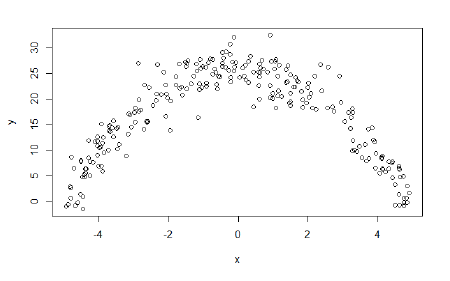

(A) A random forest is appropriate because the data contain only quantitative variables. (B) A random forest is appropriate because the data do not follow a straight line. (C) A GLM is not appropriate because the variance of $y$ given $x$ is not constant. (D) A random forest is appropriate because there is a clear relationship between $y$ and $x$. (E) A GLM is appropriate because it can accommodate polynomial relationships.

**Solution.** The points lie close to a quadratic with constant spread, so the model $y=\beta_0+\beta_1x+\beta_2x^2+\varepsilon$, linear in the coefficients, fits it, and a GLM (here the normal linear model) is appropriate: (E). (A) is no reason: trees handle qualitative predictors directly and gain nothing from quantitative ones. (B) and (D) are not reasons either: a smooth curve is what a tree approximates worst, by a staircase whose error Unit 11's theorem **approximating a linear function by boxes** quantifies, and a curve that a polynomial GLM fits is by itself no reason to prefer a forest. (C) is false: the spread looks constant. ■